In [1]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def read_near2d_log(file_path: str) -> dict:
    frequency = None
    header = []
    data_lines = []

    with open(file_path, 'r') as f:
        for i, line in enumerate(f):
            line = line.strip()
            if not line:
                continue

            if i == 0:
                # Extract frequency from the first line
                match = re.search(r'frequency\[Hz\] = (\d+\.\d+e[+\-]\d+)', line)
                if match:
                    frequency = float(match.group(1))
                else:
                    print(f"Warning: Could not extract frequency from the first line: {line}")
            elif i == 1:
                # This line contains column headers, but some are multi-word or have units.
                # Let's clean them up.
                raw_headers = line.split()
                # Manually adjust headers to be single words for DataFrame
                # Based on the example: No. No. X[m] Y[m] Z[m] E[V/m] Ex[V/m] Ex[deg] Ey[V/m] Ey[deg] Ez[V/m] Ez[deg]
                # Assuming the first two "No." are indices, we might rename them or keep as is.
                # For simplicity, let's just use them as is and pandas will handle duplicates by suffixing.
                header = [
                    'No_idx1', 'No_idx2', 'X[m]', 'Y[m]', 'Z[m]', 'E[V/m]',
                    'Ex[V/m]', 'Ex[deg]', 'Ey[V/m]', 'Ey[deg]', 'Ez[V/m]', 'Ez[deg]'
                ]
            else:
                # Data lines
                parts = line.split()
                if len(parts) == len(header):
                    try:
                        # Convert to appropriate types (int for indices, float for others)
                        parsed_parts = [int(parts[0]), int(parts[1])] + [float(p) for p in parts[2:]]
                        data_lines.append(parsed_parts)
                    except ValueError as e:
                        print(f"Warning: Could not parse line '{line}' as numerical data. Skipping. Error: {e}")
                else:
                    print(f"Warning: Line '{line}' has {len(parts)} columns, expected {len(header)}. Skipping.")

    if not header:
        raise ValueError("Could not determine header from the file.")
    if not data_lines:
        print("Warning: No data lines were parsed from the file.")

    df = pd.DataFrame(data_lines, columns=header)

    return {'frequency': frequency, 'data': df}


In [25]:
try:
    log_data = read_near2d_log('near2dSC.log')
    print(f"Frequency: {log_data['frequency']} Hz")
    print("Data Head:")
    print(log_data['data'].head(3))
#    print("\nData Info:")
#    log_data['data'].info()
except FileNotFoundError:
    print("Error: near2d.log not found. Please make sure the file is in the correct directory.")
except Exception as e:
    print(f"An error occurred: {e}")

Frequency: 3000000000.0 Hz
Data Head:
   No_idx1  No_idx2  X[m]  Y[m]  Z[m]  E[V/m]       Ex[V/m]  Ex[deg]  \
0        0        0 -0.15 -0.15   0.0  0.4712  2.154000e-17  120.741   
1        0        1 -0.15 -0.14   0.0  0.4635  1.744000e-17  127.168   
2        0        2 -0.15 -0.13   0.0  0.4376  1.298000e-17  129.540   

        Ey[V/m]  Ey[deg]  Ez[V/m]  Ez[deg]  
0  1.898000e-17  -54.973   0.4712  -66.611  
1  2.075000e-17  -28.694   0.4635  -59.166  
2  2.496000e-17  -11.882   0.4376  -50.644  


In [26]:
data = log_data['data']

In [27]:
d = np.zeros((31,31))
p = np.zeros((31,31))
adr = 0
for ix in range(31):
    for iy in range(31):
        d[ix][iy] = data['Ez[V/m]'][adr]
        p[ix][iy] = data['Ez[deg]'][adr]
        adr = adr + 1

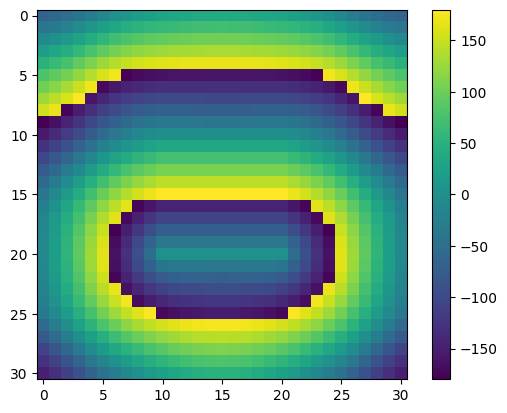

In [28]:
plt.imshow(p)
plt.colorbar()

In [29]:
c = d*np.exp(1j*p/180*np.pi)

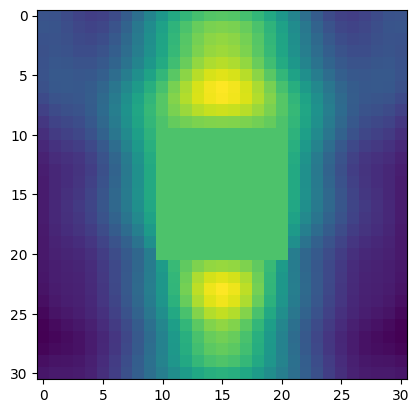

In [30]:
plt.imshow(np.abs(c))

In [9]:
np.save("c.npy", c)

In [10]:
try:
    log_data = read_near2d_log('near2d.log')
    print(f"Frequency: {log_data['frequency']} Hz")
    print("Data Head:")
    print(log_data['data'].head(3))
#    print("\nData Info:")
#    log_data['data'].info()
except FileNotFoundError:
    print("Error: near2d.log not found. Please make sure the file is in the correct directory.")
except Exception as e:
    print(f"An error occurred: {e}")

Frequency: 3000000000.0 Hz
Data Head:
   No_idx1  No_idx2  X[m]  Y[m]  Z[m]  E[V/m]       Ex[V/m]  Ex[deg]  Ey[V/m]  \
0        0        0 -0.15 -0.15   0.0     1.0  6.123000e-17   -0.374      0.0   
1        0        1 -0.15 -0.14   0.0     1.0  6.123000e-17   -0.374      0.0   
2        0        2 -0.15 -0.13   0.0     1.0  6.123000e-17   -0.374      0.0   

   Ey[deg]  Ez[V/m]  Ez[deg]  
0     -0.0      1.0  179.626  
1     -0.0      1.0  179.626  
2     -0.0      1.0  179.626  


In [11]:

data = log_data['data']
d = np.zeros((31,31))
adr = 0
for ix in range(31):
    for iy in range(31):
        d[ix][iy] = data['Ez[deg]'][adr]
        adr = adr + 1


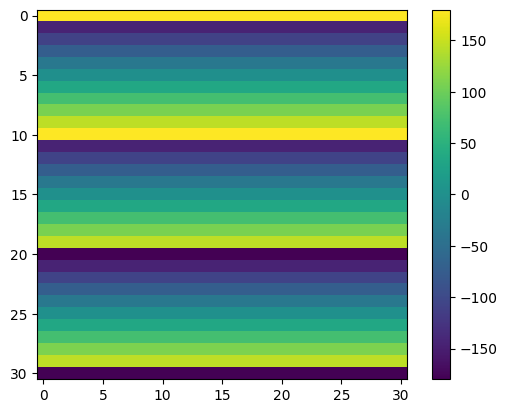

In [12]:
plt.imshow(d)
plt.colorbar()